In [1]:
import pandas as pd
import rioxarray 
import os
import xarray as xr
import dask
from datetime import datetime
import hvplot.xarray
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
from rioxarray.merge import merge_datasets, merge_arrays
import shapely
import threading
from tqdm.notebook import tqdm

os.environ['AWS_NO_SIGN_REQUEST'] = 'YES' 

# other requirements
# * hvplot requires datashader package 

In [2]:
bucket_name = 'hls-composite-bdec'
# Mexico tiles
tile_list = ["15QYA", "15QYV", "15QZA", "15QZV", "16QBE", "16QBF", "16QCE", "16QCF"]
shapefile_path = r"../geojson/Mexico.geojson"

# Alabama tiles
#tile_list = ["16RDU", "16RDV", "16REU", "16REV", "16RFV", "16RGV", "16SDA", "16SDB", "16SEA", "16SEB", "16SEC", "16SED", "16SFA", "16SFB", "16SFC", "16SFD", "16SGA", "16SGB"]
#shapefile_path = r"../geojson/alabama.geojson"

# Jamaica tiles
# tile_list = ["17QRV", "17QRA", "18QUE", "18QUF"] 
# shapefile_path = r"../geojson/jamaica.geojson"

output_dir =  "../output"

year = "2020"

## Composite algorithm. 
## initial data: 'median-30day', 'median-10day', 'max-30day'
## Step-1 data : 'max-10day', 'median-10day', 'max-monthly', 'median-monthly'
## Step-2 data : 'median-10day', 'median-monthly'
composite_alg = "median-monthly"
no_data_value = -9999

In [3]:
def get_list_of_files_from_s3(bucket_name, prefix):
    """
        function to get s3 file links from bucket and prefix
    """
    import boto3
    from botocore import UNSIGNED
    from botocore.client import Config

    s3 = boto3.resource('s3', config=Config(signature_version=UNSIGNED))
    bucket = s3.Bucket(bucket_name)
    
    files = []
    for obj in bucket.objects.filter(Prefix=prefix):
        files.append(f"s3://{bucket_name}/"+obj.key)
    return files

def gen_prefix(composite_alg="median-10day", year="2018", tile="15QYA", granule_name=""):
    """
        construct prefix from variables
        UPDATE the prefix if needed
    """
    ## prefix for 'initial' results 
    # return f'test-composite-{composite_alg}/{tile}/{year}/{granule_name}'
   
    ## Step-1 prototype results 
    return  f'step-2-evaluation-prototype-data/composite-{composite_alg}/{tile}/{year}/{granule_name}'

## Process granules 
s3_file_links = []
for tile in tile_list:
    prefix = gen_prefix(composite_alg=composite_alg, year=year, tile=tile)
    s3_file_links.extend(get_list_of_files_from_s3(bucket_name, prefix))

In [4]:
# print first few links in the list 
s3_file_links[:10]

['s3://hls-composite-bdec/step-2-evaluation-prototype-data/composite-median-monthly/15QYA/2020/HLS.M30.T15QYA.2020001.2020031.2.0/HLS.M30.T15QYA.2020001.2020031.2.0.Blue.std.tif',
 's3://hls-composite-bdec/step-2-evaluation-prototype-data/composite-median-monthly/15QYA/2020/HLS.M30.T15QYA.2020001.2020031.2.0/HLS.M30.T15QYA.2020001.2020031.2.0.Blue.tif',
 's3://hls-composite-bdec/step-2-evaluation-prototype-data/composite-median-monthly/15QYA/2020/HLS.M30.T15QYA.2020001.2020031.2.0/HLS.M30.T15QYA.2020001.2020031.2.0.DOY.tif',
 's3://hls-composite-bdec/step-2-evaluation-prototype-data/composite-median-monthly/15QYA/2020/HLS.M30.T15QYA.2020001.2020031.2.0/HLS.M30.T15QYA.2020001.2020031.2.0.Fmask.tif',
 's3://hls-composite-bdec/step-2-evaluation-prototype-data/composite-median-monthly/15QYA/2020/HLS.M30.T15QYA.2020001.2020031.2.0/HLS.M30.T15QYA.2020001.2020031.2.0.Green.std.tif',
 's3://hls-composite-bdec/step-2-evaluation-prototype-data/composite-median-monthly/15QYA/2020/HLS.M30.T15QYA.2

In [5]:
# subset links to separate bands
s3_file_links_red = [f for f in s3_file_links if 'Red.tif' in f]
s3_file_links_nir = [f for f in s3_file_links if 'NIR_Narrow.tif' in f]

In [6]:
composite_duration = [".".join(link.split(".")[3:5]) for link in s3_file_links_red if tile_list[0] in link]
composite_duration

['2020001.2020031',
 '2020032.2020060',
 '2020061.2020091',
 '2020092.2020121',
 '2020122.2020152',
 '2020153.2020182',
 '2020183.2020213',
 '2020214.2020244',
 '2020245.2020274',
 '2020275.2020305',
 '2020306.2020335',
 '2020336.2020366']

In [7]:
len(s3_file_links_red)

96

In [8]:
# get links for first composite duration
s3_file_links_red_duration0 = [f for f in s3_file_links_red if composite_duration[0] in f]

In [9]:
def read_rasters(raster_paths, target_crs):
    for path in raster_paths:
        # Load with chunks to keep memory usage low (Dask)
        da = rioxarray.open_rasterio(path, lock=False, chunks={'x': 3660, 'y': 3660}, mask_and_scale=True)
        
        # 2. Reproject if the CRS doesn't match the target
        if da.rio.crs != target_crs:
            # 'reproject' calculates the new coordinates and transforms
            da = da.rio.reproject(target_crs)
            
        processed_arrays.append(da)
    return processed_arrays

def plot_shapefile_and_tiles(gdf1, gdf2):
    fig, ax = plt.subplots(1, 1)
    fig.set_size_inches(5,5)
    gdf2.plot(
            ax=ax,
            facecolor='none',
            edgecolor='black',
            alpha=0.5)

    gdf1.plot(
            ax=ax,
            facecolor='blue',
            alpha=0.5)
#         ax.set_axis_off()
    plt.show()
    
def mosaic_reproject_clip(raster_links, shapefile_path, output_crs=None, nodata=-9999, clip=False, plot=False):
    """
    raster_paths: GeoTIFFS S3 links 
    shapefile_path: Loads a shapefile of the study area
    
    This function
    1. Loads a shapefile.
    2. Reprojects all rasters to a common CRS.
    3. Mosaics them into one xarray.
    4. Clips to the shapefile boundary.
    
    """
    # 1. Load the shapefile to define the study area
    gdf = gpd.read_file(shapefile_path)
    
    # If no output_crs is provided, use the shapefile's CRS as the "Master"
    if output_crs is None:
        target_crs = gdf.crs
    else:
        target_crs = output_crs

    processed_arrays = []
    processed_arrays = read_rasters(raster_links, target_crs)

    #  Merge (Mosaic) the aligned rasters
    # All rasters MUST have the same CRS for merge_arrays to work
    merged = merge_arrays(processed_arrays)
    
    #print("Done merging rasters")
    if clip:
        # Clip to the shapefile
        # Ensure shapefile matches the target_crs (just in case)
        if gdf.crs != target_crs:
            gdf = gdf.to_crs(target_crs)

        # Apply the clip
        clipped = merged.rio.clip(
            gdf.geometry.apply(lambda g: g.__geo_interface__),
            crs=target_crs,
            drop=True
        )
        # Set the nodata value properly in the metadata
        clipped = clipped.rio.write_nodata(nodata, encoded=True)
        #print("Done clipping rasters to shapefile")
    
        return clipped
    else:
        return merged

In [10]:
# 1. Load the shapefile to define the study area
gdf = gpd.read_file(shapefile_path)
target_crs = gdf.crs

#print(f"Aligning {len(raster_paths)} rasters to CRS: {target_crs}")
processed_arrays = []
processed_arrays = read_rasters(s3_file_links_red_duration0, target_crs)
#print("Done loading rasters")  

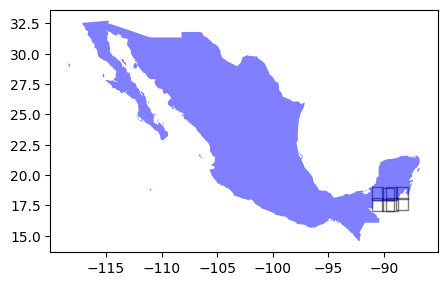

In [11]:
## Plot shape file and tile boundaries
bboxes = []
for ds in processed_arrays:
        bounds = ds.rio.bounds()
        bbox = shapely.box(*bounds)  # Create a shapely box object
        bboxes.append(bbox)
    
gdf2 = gpd.GeoDataFrame(geometry=bboxes, crs=processed_arrays[0].rio.crs)
plot_shapefile_and_tiles(gdf, gdf2)

In [ ]:
## Mosaic example
## Loop through composites, merge and save ndvi rasters
for i in tqdm(range(len(composite_duration))):
    duration = composite_duration[i]
    
    print(f"Processing {duration}")
    s3_file_links_red_duration = [f for f in s3_file_links_red if duration in f]
    s3_file_links_nir_duration = [f for f in s3_file_links_nir if duration in f]
    
    # Mosaic and clip
    mosaic_da_red = mosaic_reproject_clip(s3_file_links_red_duration, shapefile_path, nodata=-9999, clip=True, plot=False)
    mosaic_da_nir = mosaic_reproject_clip(s3_file_links_nir_duration, shapefile_path, nodata=-9999, clip=True, plot=False)

    # calculate NDVI from red and nir bands
    mosaic_ndvi = (mosaic_da_nir - mosaic_da_red)/(mosaic_da_nir + mosaic_da_red)
    mosaic_ndvi.name = "NDVI"

    # write mosaic ndvi 
    mosaic_ndvi.rio.to_raster(f"{output_dir}/mosaic_ndvi_{duration}.tif", tiled=True, lock=threading.Lock())

print(f"Done Mosaicing")


  0%|          | 0/12 [00:00<?, ?it/s]

Processing 2020001.2020031


/usr/local/lib/python3.10/site-packages/geopandas/geoseries.py:645: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  result = super().apply(func, convert_dtype=convert_dtype, args=args, **kwargs)
